# 🌲 Notebook 03: Machine Learning — Random Forest for Dropout Prediction

---

## 🎯 Objetivo

Train a **Random Forest** model to predict which patients will dropout of TB treatment, and translate ML metrics into actionable public health KPIs.

### Why Random Forest and not XGBoost here?

This portfolio intentionally uses **different algorithms** across projects to demonstrate breadth — not because RF is always optimal.

| Aspecto | Proyecto A (FasR) — XGBoost | Proyecto B (TB Churn) — Random Forest |
|---------|----------------------------|-----------------------------------------|
| Feature types | Binary (fingerprints) | Mixed (continuous + categorical) |
| Interpretabilidad | SHAP (post-hoc) | RF nativo + LIME (local) |
| Audience | Pharma researchers | Public health staff |
| Dataset size | 500 molecules | 800 patients |
| Message | "Maximum performance" | "Interpretable and actionable" |

**Random Forest is preferred here because:**
- LIME local explanations are more stable with RF
- Lower overfitting risk on small-to-medium datasets
- Feature importances are more robust to communicate to clinicians
- Less exhaustive tuning required (narrower hyperparameter range)

### Primary metric: Cost-Sensitive Learning
> In public health, errors have asymmetric costs:  
> - **False Negative** (missed future dropout): high cost → patient lost to follow-up, potential drug resistance
> - **False Positive** (unnecessary alert): low cost → visita extra del trabajador social
> 
> Por eso optimizamos **Recall** y entendemos el trade-off con Precision.

In [1]:
import sys, os, pickle, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    StratifiedKFold, cross_validate, train_test_split, RandomizedSearchCV
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

sys.path.append('../src')
from feature_engineering import (
    load_and_merge, engineer_features, prepare_ml_dataset
)

sns.set_theme(style='whitegrid')
os.makedirs('../models', exist_ok=True)
os.makedirs('../figures', exist_ok=True)

print('✅ Imports OK')

✅ Imports OK


## 1. Load and Prepare Data

In [2]:
df = pd.read_csv('../data/processed/ml_dataset.csv')

with open('../models/feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)

X, y, _, _, _ = prepare_ml_dataset(df, encode_categoricals=True)

# Train/Test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} patients | Test: {X_test.shape[0]} patients')
print(f'Dropout rate  Train: {y_train.mean()*100:.1f}% | Test: {y_test.mean()*100:.1f}%')

# Pesos de clase para manejar el imbalance
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
cw_dict = {0: class_weights[0], 1: class_weights[1]}
print(f'\nClass weights: {cw_dict}')

  Feature matrix: 800 patients x 29 features
    Numeric:      5
    Binary:       11
    Categorical:  13 (encoded)

  Target (dropout_label):
    Defaulted:  157 (19.6%)
    Completed:  643 (80.4%)
Train: 640 patients | Test: 160 patients
Dropout rate  Train: 19.7% | Test: 19.4%

Class weights: {0: np.float64(0.622568093385214), 1: np.float64(2.5396825396825395)}


## 2. Baseline y Cross-Validation

In [3]:
print('=== BASELINE: Random Forest default + class_weight ===')

rf_baseline = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    rf_baseline, X_train, y_train, cv=cv,
    scoring=['roc_auc', 'average_precision', 'recall', 'precision', 'f1'],
    return_train_score=False
)

print(f'\nCross-Validation (5-fold) — Baseline:')
for metric in ['roc_auc', 'average_precision', 'recall', 'precision', 'f1']:
    scores = cv_results[f'test_{metric}']
    print(f'  {metric:20s}: {scores.mean():.3f} ± {scores.std():.3f}')

=== BASELINE: Random Forest default + class_weight ===

Cross-Validation (5-fold) — Baseline:
  roc_auc             : 0.639 ± 0.020
  average_precision   : 0.335 ± 0.055
  recall              : 0.024 ± 0.032
  precision           : 0.333 ± 0.422
  f1                  : 0.044 ± 0.058


## 3. Hyperparameter Tuning with RandomizedSearchCV

In [4]:
from scipy.stats import randint

PARAM_DIST = {
    'n_estimators': randint(100, 600),
    'max_depth': [None, 5, 8, 12, 20],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', 0.3, 0.5],
    'bootstrap': [True, False],
}

rf_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    rf_model,
    param_distributions=PARAM_DIST,
    n_iter=50,
    scoring='average_precision',   # AP > ROC para datos imbalanceados
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

print('Ejecutando RandomizedSearchCV (50 iteraciones)...')
random_search.fit(X_train, y_train)

print(f'\nBest parameters:')
for k, v in random_search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nMejor AP (CV): {random_search.best_score_:.4f}')

Ejecutando RandomizedSearchCV (50 iteraciones)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters:
  bootstrap: True
  max_depth: None
  max_features: sqrt
  min_samples_leaf: 6
  min_samples_split: 13
  n_estimators: 143

Mejor AP (CV): 0.3800


## 4. Test Set Evaluation

=== TEST SET EVALUATION ===
  AUC-ROC:           0.5841
  Average Precision: 0.2893

              precision    recall  f1-score   support

   Completed       0.83      0.86      0.85       129
     Dropout       0.33      0.29      0.31        31

    accuracy                           0.75       160
   macro avg       0.58      0.58      0.58       160
weighted avg       0.74      0.75      0.74       160



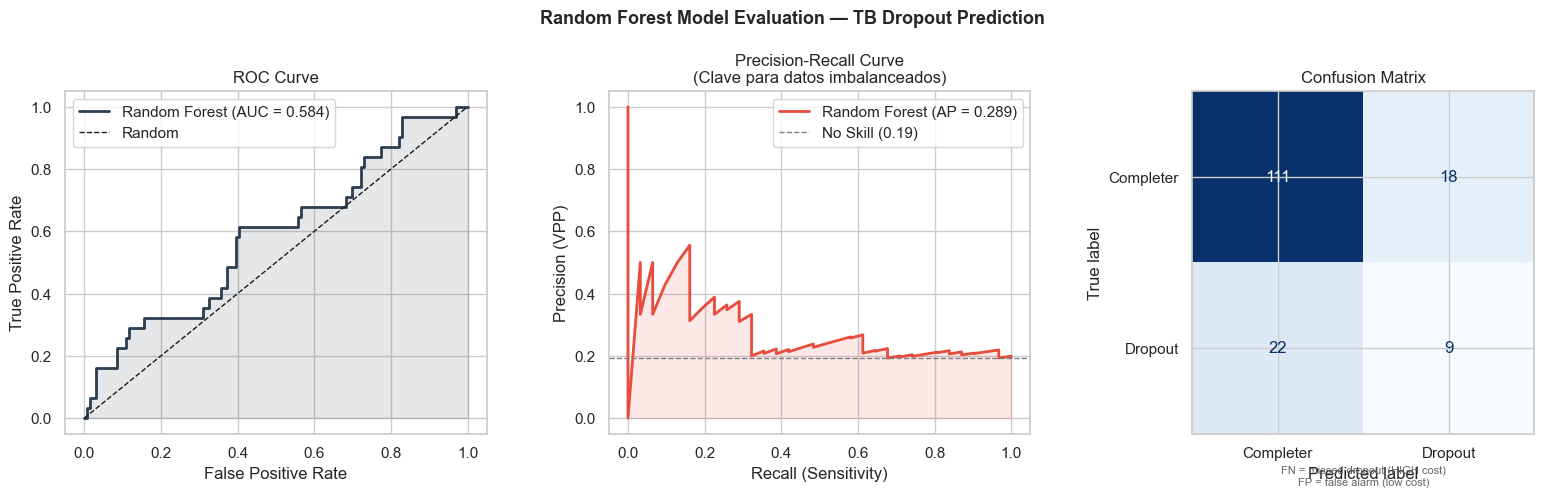

In [5]:
best_rf = random_search.best_estimator_

y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

auc_roc = roc_auc_score(y_test, y_prob)
avg_prec = average_precision_score(y_test, y_prob)

print('=== TEST SET EVALUATION ===')
print(f'  AUC-ROC:           {auc_roc:.4f}')
print(f'  Average Precision: {avg_prec:.4f}')
print(f'\n{classification_report(y_test, y_pred, target_names=["Completed", "Dropout"])}')

# ── Curvas ROC + Precision-Recall ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, color='#2C3E50', lw=2,
              label=f'Random Forest (AUC = {auc_roc:.3f})')
axes[0].plot([0,1],[0,1], 'k--', lw=1, label='Random')
axes[0].fill_between(fpr, tpr, alpha=0.12, color='#2C3E50')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

# Precision-Recall
prec, rec, _ = precision_recall_curve(y_test, y_prob)
no_skill = y_test.mean()
axes[1].plot(rec, prec, color='#E74C3C', lw=2,
              label=f'Random Forest (AP = {avg_prec:.3f})')
axes[1].axhline(no_skill, color='gray', linestyle='--', lw=1,
                 label=f'No Skill ({no_skill:.2f})')
axes[1].fill_between(rec, prec, alpha=0.12, color='#E74C3C')
axes[1].set_xlabel('Recall (Sensitivity)')
axes[1].set_ylabel('Precision (VPP)')
axes[1].set_title('Precision-Recall Curve\n(Clave para datos imbalanceados)')
axes[1].legend()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Completer', 'Dropout'])
disp.plot(ax=axes[2], cmap='Blues', colorbar=False)
axes[2].set_title('Confusion Matrix')

# Interpretive cost annotation
axes[2].text(0.5, -0.15,
              'FN = missed dropout (HIGH cost)\nFP = false alarm (low cost)',
              ha='center', fontsize=8, transform=axes[2].transAxes, color='#666')

fig.suptitle('Random Forest Model Evaluation — TB Dropout Prediction',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/08_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Translation to Public Health Impact

This section converts technical metrics into **public health KPIs** — the bridge between a data science model and real-world deployment.


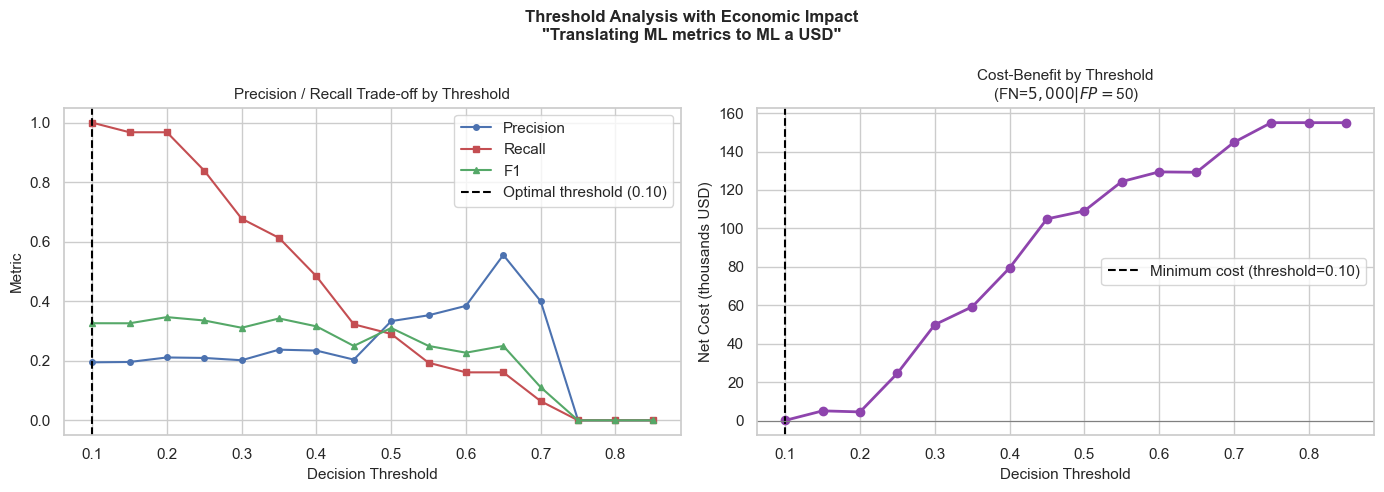


=== COST-OPTIMAL THRESHOLD ===
  Threshold: 0.10
  Recall (Sensitivity): 1.000
  Precision (PPV):       0.195
  Patients flagged:      159
  Estimated net cost:    $200 USD

💡 Program manager takeaway:
   "Con threshold=0.10, detectamos 100% de los
    dropouts before they occur — proactively flagging 159 at-risk patients"


In [6]:
# Threshold analysis with program cost
thresholds = np.arange(0.1, 0.9, 0.05)
results = []

# Cost assumptions (adjustable by the TB program manager)
COST_FN = 5000   # USD: undetected dropout — retreatment + MDR risk → retratamiento + riesgo MDR
COST_FP = 50     # USD: visita extra del trabajador social (innecesaria)
COST_TP = -200   # USD: savings from early dropout prevention

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    tp = ((y_pred_t == 1) & (y_test == 1)).sum()
    fp = ((y_pred_t == 1) & (y_test == 0)).sum()
    fn = ((y_pred_t == 0) & (y_test == 1)).sum()
    tn = ((y_pred_t == 0) & (y_test == 0)).sum()

    prec = tp / (tp + fp + 1e-9)
    rec  = tp / (tp + fn + 1e-9)
    f1   = 2 * prec * rec / (prec + rec + 1e-9)
    cost = tp * COST_TP + fp * COST_FP + fn * COST_FN
    patients_flagged = (y_pred_t == 1).sum()

    results.append({
        'threshold': round(t, 2),
        'precision': prec, 'recall': rec, 'f1': f1,
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'net_cost_usd': cost,
        'patients_flagged': patients_flagged,
    })

df_thresh = pd.DataFrame(results)

# Optimal threshold = minimum net cost
opt_idx = df_thresh['net_cost_usd'].idxmin()
opt = df_thresh.iloc[opt_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(df_thresh['threshold'], df_thresh['precision'], 'b-o', ms=4, label='Precision')
ax1.plot(df_thresh['threshold'], df_thresh['recall'], 'r-s', ms=4, label='Recall')
ax1.plot(df_thresh['threshold'], df_thresh['f1'], 'g-^', ms=4, label='F1')
ax1.axvline(opt['threshold'], color='black', linestyle='--', lw=1.5,
             label=f'Optimal threshold ({opt["threshold"]:.2f})')
ax1.set_xlabel('Decision Threshold', fontsize=11)
ax1.set_ylabel('Metric', fontsize=11)
ax1.set_title('Precision / Recall Trade-off by Threshold', fontsize=11)
ax1.legend()

ax2.plot(df_thresh['threshold'], df_thresh['net_cost_usd'] / 1000, 'o-',
          color='#8E44AD', linewidth=2)
ax2.axvline(opt['threshold'], color='black', linestyle='--', lw=1.5,
             label=f'Minimum cost (threshold={opt["threshold"]:.2f})')
ax2.axhline(0, color='gray', linestyle='-', lw=0.8)
ax2.set_xlabel('Decision Threshold', fontsize=11)
ax2.set_ylabel('Net Cost (thousands USD)', fontsize=11)
ax2.set_title(f'Cost-Benefit by Threshold\n(FN=${COST_FN:,} | FP=${COST_FP:,})',
               fontsize=11)
ax2.legend()

plt.suptitle('Threshold Analysis with Economic Impact\n"Translating ML metrics to ML a USD"',
              fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/09_threshold_cost_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n=== COST-OPTIMAL THRESHOLD ===')
print(f'  Threshold: {opt["threshold"]:.2f}')
print(f'  Recall (Sensitivity): {opt["recall"]:.3f}')
print(f'  Precision (PPV):       {opt["precision"]:.3f}')
print(f'  Patients flagged:      {int(opt["patients_flagged"])}')
print(f'  Estimated net cost:    ${opt["net_cost_usd"]:,.0f} USD')
print(f'\n💡 Program manager takeaway:')
print(f'   "Con threshold={opt["threshold"]:.2f}, detectamos {opt["recall"]*100:.0f}% de los')
print(f'    dropouts before they occur — proactively flagging {int(opt["patients_flagged"])} at-risk patients"')

## 6. Feature Importance & Save Model

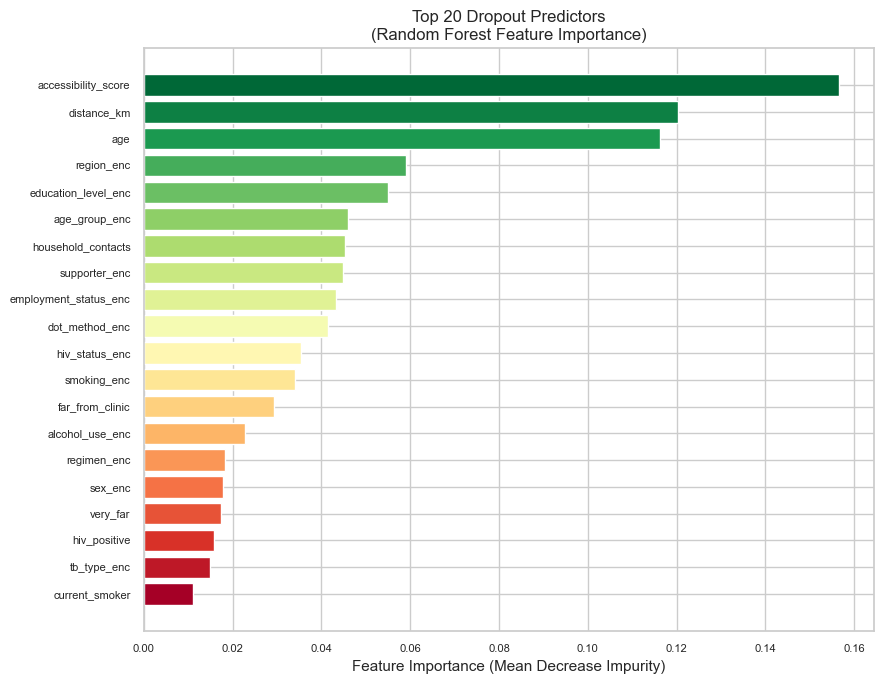


✅ Model saved to models/rf_tb_model.pkl
✅ Optimal threshold saved to models/optimal_threshold.pkl


In [7]:
# Feature importance del Random Forest
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 7))
colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(importance_df)))
bars = ax.barh(importance_df['feature'][::-1],
                importance_df['importance'][::-1],
                color=colors[::-1], edgecolor='white')
ax.set_xlabel('Feature Importance (Mean Decrease Impurity)', fontsize=11)
ax.set_title('Top 20 Dropout Predictors\n(Random Forest Feature Importance)',
              fontsize=12)
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.savefig('../figures/10_feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()

# Save model
with open('../models/rf_tb_model.pkl', 'wb') as f:
    pickle.dump(best_rf, f)
with open('../models/optimal_threshold.pkl', 'wb') as f:
    pickle.dump({'threshold': opt['threshold']}, f)

print('\n✅ Model saved to models/rf_tb_model.pkl')
print('✅ Optimal threshold saved to models/optimal_threshold.pkl')